## Assessing the Impact of Documenting Dataset Composition for Model Training—Whether Imbalanced or Balanced—on AI Model Transparency and Fairness


In [96]:
import os
print(os.getcwd())

C:\Users\HENNY PURWADI\PYTHON\HULL\771949_Ethical


In [279]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', 160)

# Scikit-learn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve, auc

# Optional (for handling class imbalance)
from imblearn.over_sampling import SMOTE

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [311]:
# Create synthetic dataset (extremely imbalanced)
X, y = make_classification(n_samples=1000000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9999, 0.0001], flip_y=0, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [313]:
# Train a Logistic Regression classifier on imbalanced data
clf_imbalanced = LogisticRegression(random_state=42)
clf_imbalanced.fit(X_train, y_train)

# Make predictions and show classification report for imbalanced data
y_pred_imbalanced = clf_imbalanced.predict(X_test)
print("Classification Report for Extremely Imbalanced Data:\n")
print(classification_report(y_test, y_pred_imbalanced))

Classification Report for Extremely Imbalanced Data:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199973
           1       0.00      0.00      0.00        27

    accuracy                           1.00    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       1.00      1.00      1.00    200000



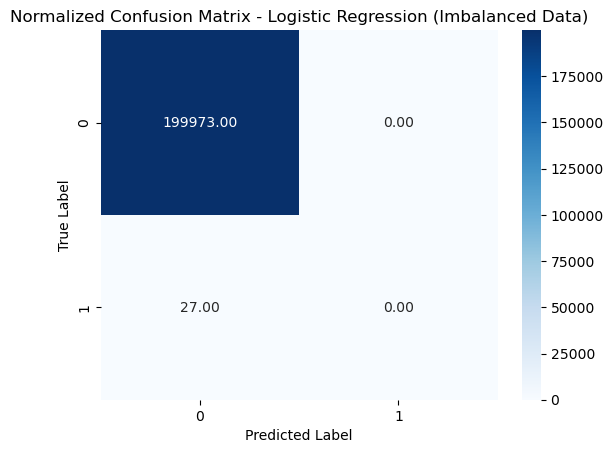

In [332]:
# Plot normalized heatmap for confusion matrix of imbalanced data
conf_matrix = confusion_matrix(y_test, y_pred_imbalanced)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Normalized Confusion Matrix - Logistic Regression (Imbalanced Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

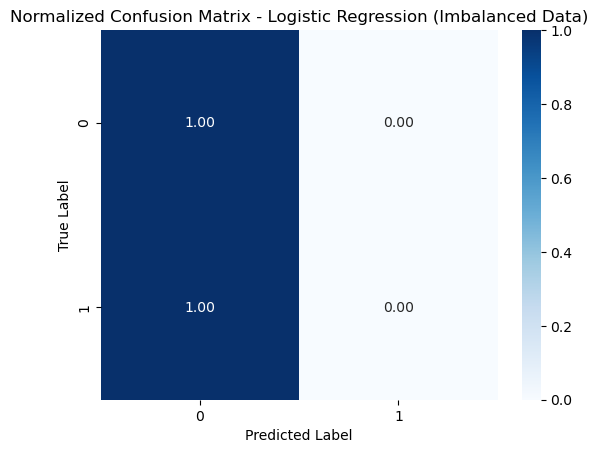

In [314]:
# Plot normalized heatmap for confusion matrix of imbalanced data
conf_matrix = confusion_matrix(y_test, y_pred_imbalanced, normalize='true')
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Normalized Confusion Matrix - Logistic Regression (Imbalanced Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Interpretation:

The extremely imbalanced dataset results in a model that is unable to effectively identify the minority class. The recall for the minority class (class 1) is 0, showing that the model fails to detect any true positives. It's not caused by the Model, but caused by the Imbalance Dataset.

The model is highly biased towards the majority class due to the extreme imbalance (99.9% of class 0 vs. 0.1% of class 1). In the confusion matrix, the recall for class 1 is 0.


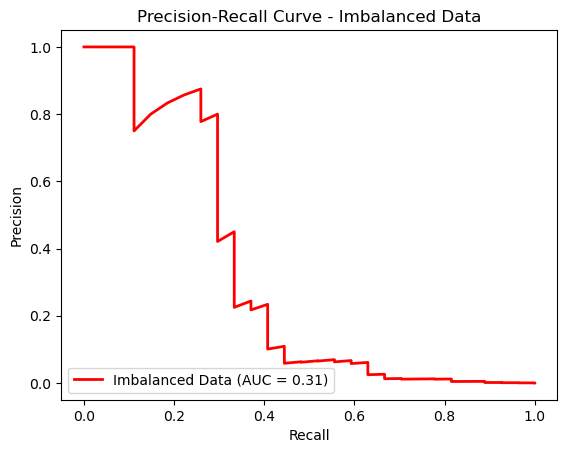

In [318]:
# Precision-Recall Curve for imbalanced data
y_prob_imbalanced = clf_imbalanced.decision_function(X_test)
precision_imbalanced, recall_imbalanced, _ = precision_recall_curve(y_test, y_prob_imbalanced)
pr_auc_imbalanced = auc(recall_imbalanced, precision_imbalanced)

plt.plot(recall_imbalanced, precision_imbalanced, color='red', lw=2, label='Imbalanced Data (AUC = %0.2f)' % pr_auc_imbalanced)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Imbalanced Data')
plt.legend(loc='lower left')
plt.show()

In [320]:
# Create synthetic dataset (balanced)
X_bal, y_bal = make_classification(n_samples=1000000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1,
                                   weights=[0.5, 0.5], flip_y=0, random_state=42)

# Split the balanced data into training and testing sets
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

In [322]:
# Train a Logistic Regression classifier on balanced data
clf_balanced = LogisticRegression(random_state=42)
clf_balanced.fit(X_train_bal, y_train_bal)

# Make predictions and show classification report for balanced data
y_pred_balanced = clf_balanced.predict(X_test_bal)
print("\nClassification Report for Balanced Data:\n")
print(classification_report(y_test_bal, y_pred_balanced))


Classification Report for Balanced Data:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     99945
           1       0.97      0.99      0.98    100055

    accuracy                           0.98    200000
   macro avg       0.98      0.98      0.98    200000
weighted avg       0.98      0.98      0.98    200000



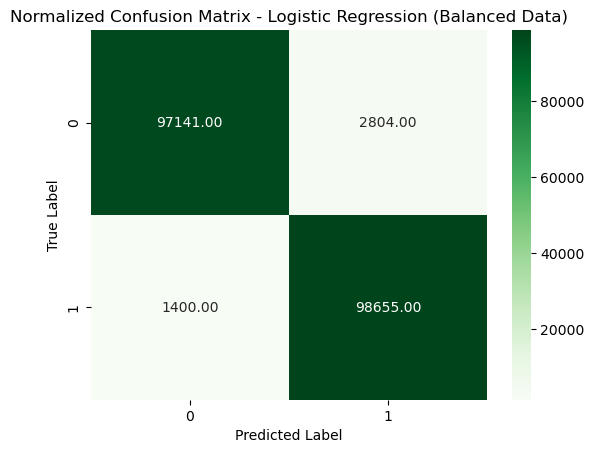

In [344]:
# Plot normalized heatmap for confusion matrix of balanced data
conf_matrix_bal = confusion_matrix(y_test_bal, y_pred_balanced)
sns.heatmap(conf_matrix_bal, annot=True, cmap='Greens', fmt='.2f')
plt.title("Normalized Confusion Matrix - Logistic Regression (Balanced Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

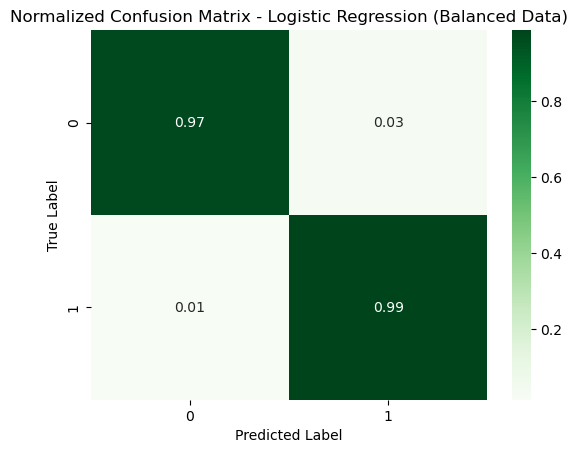

In [346]:
# Plot normalized heatmap for confusion matrix of balanced data
conf_matrix_bal = confusion_matrix(y_test_bal, y_pred_balanced, normalize='true')
sns.heatmap(conf_matrix_bal, annot=True, cmap='Greens', fmt='.2f')
plt.title("Normalized Confusion Matrix - Logistic Regression (Balanced Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Interpretation

In the balanced dataset, the model performs well for both classes, with high recall and precision values. The model doesn't show bias towards any specific class.

The true positive rate for both classes is close to 1, and the off-diagonal elements are very low, means that both classes are being correctly classified with high accuracy.


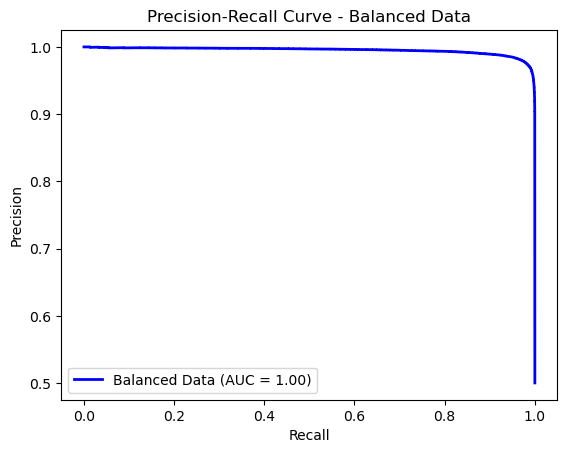

In [325]:
# Precision-Recall Curve for balanced data
y_prob_balanced = clf_balanced.decision_function(X_test_bal)
precision_balanced, recall_balanced, _ = precision_recall_curve(y_test_bal, y_prob_balanced)
pr_auc_balanced = auc(recall_balanced, precision_balanced)

plt.plot(recall_balanced, precision_balanced, color='blue', lw=2, label='Balanced Data (AUC = %0.2f)' % pr_auc_balanced)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Balanced Data')
plt.legend(loc='lower left')
plt.show()

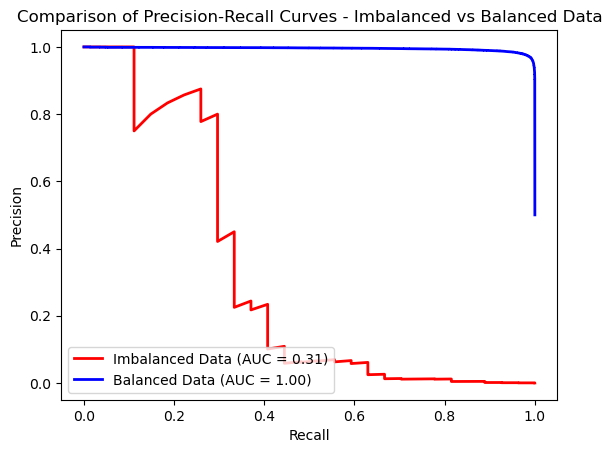

In [328]:
# Comparison of Precision-Recall Curves
plt.plot(recall_imbalanced, precision_imbalanced, color='red', lw=2, label='Imbalanced Data (AUC = %0.2f)' % pr_auc_imbalanced)
plt.plot(recall_balanced, precision_balanced, color='blue', lw=2, label='Balanced Data (AUC = %0.2f)' % pr_auc_balanced)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparison of Precision-Recall Curves - Imbalanced vs Balanced Data')
plt.legend(loc='lower left')
plt.show()

##### Interpretation:

The area under the precision-recall curve (AP) for Balanced Data is higher than Imbalanced Data , mean sthe model performs very well when the dataset is balanced. 
The balanced data allows the model to learn more effectively about both classes, reducing bias and has better overall performance.

The imbalanced dataset makes it difficult for the model to accurately identify the minority class, leading to poor performance in terms of precision when trying to recall many positives.

With balanced data, the model shows high precision across various recall levels, indicating a more fair and unbiased learning process for both classes.